# Ejercicio
Para una distribucion hipotetica normal de parametros $\mu=50$ y $\sigma=1.5$ que da lugar a una muestra $X_1,...,X_n$ (utiliza el $n$ de tu eleccion) comprueba a traves de simulacion que un $95\%$ de los intervalos de confianza bootstrap de cobertura de $0.95$ para $\sigma$ contienen el verdadero parametro $\sigma$.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
from tqdm import tqdm

In [13]:
# Parámetros de la distribución
mu = 50
sigma_true = 1.5

# Parámetros de la simulación
n = 100  # Tamaño de la muestra
n_bootstrap = 1000  # Número de remuestras bootstrap
n_simulations = 1000  # Número de simulaciones
alpha = 0.05  # Nivel de significancia

# Almacenamiento de resultados
bootstrap_means = []
ci_intervals = []
coverages = []

# Simulación principal
for _ in tqdm(range(n_simulations), desc="Simulando", unit="sim"):
    # Generar muestra original
    sample = np.random.normal(mu, sigma_true, n)
    
    # Usamos bootstrap (calcula IC y guarda remuestras)
    res = bootstrap(
        data=(sample,), 
        statistic=np.std, 
        n_resamples=n_bootstrap,
        confidence_level=1-alpha,
        method='percentile'
    )
    # Extraemos resultados
    lower, upper = res.confidence_interval.low, res.confidence_interval.high
    ci_intervals.append((lower, upper))
    
    # Verificar cobertura
    bootstrap_means.append(np.mean(res.bootstrap_distribution))
    coverages.append(lower <= sigma_true <= upper)

# Cálculo de la proporción de cobertura
coverage_proportion = np.mean(coverages)
print(f"Proporción de intervalos que contienen σ = {sigma_true}: {coverage_proportion:.3f}")

Simulando: 100%|██████████| 1000/1000 [00:01<00:00, 877.81sim/s]

Proporción de intervalos que contienen σ = 1.5: 0.928


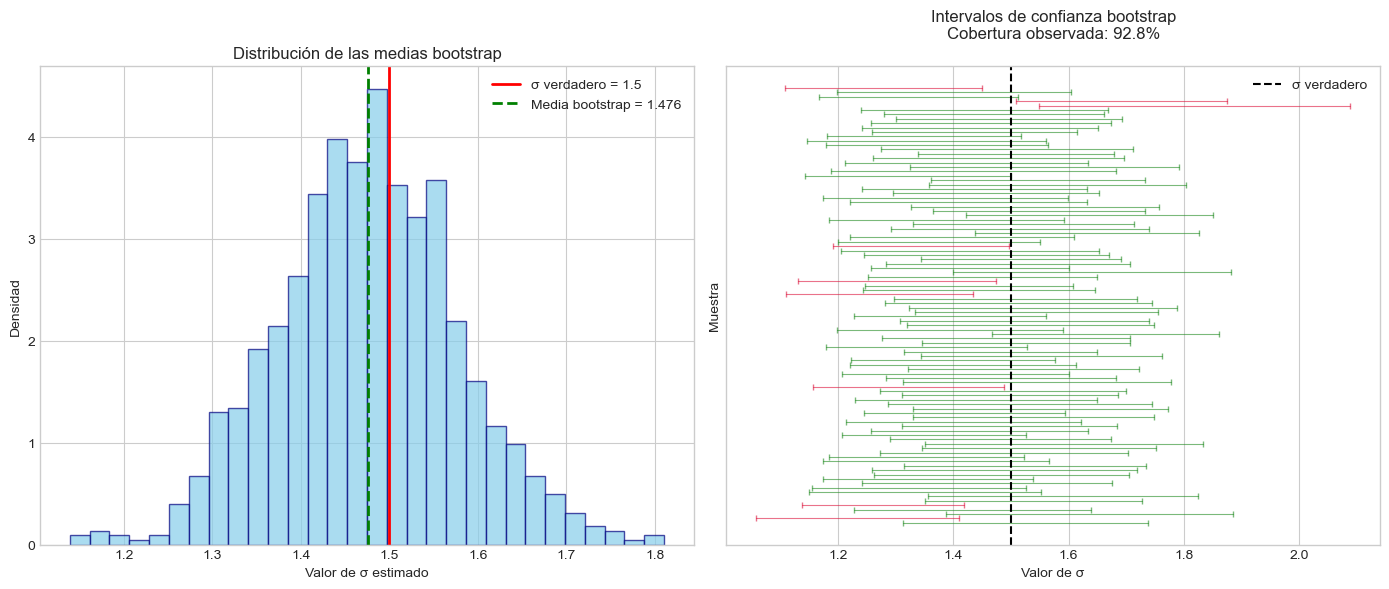

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Distribución de medias bootstrap
ax1.hist(
    bootstrap_means, 
    bins=30, 
    color='skyblue', 
    edgecolor='navy', 
    alpha=0.7,
    density=True
)
ax1.axvline(
    sigma_true, 
    color='red', 
    linestyle='-', 
    linewidth=2, 
    label=f'σ verdadero = {sigma_true}'
)
ax1.axvline(
    np.mean(bootstrap_means), 
    color='green', 
    linestyle='--', 
    linewidth=2,
    label=f'Media bootstrap = {np.mean(bootstrap_means):.3f}'
)
ax1.set_xlabel('Valor de σ estimado')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribución de las medias bootstrap')
ax1.legend()

# Gráfico 2: Intervalos de confianza
for i, (lower, upper) in enumerate(ci_intervals[:100]):
    color = 'forestgreen' if (lower <= sigma_true <= upper) else 'crimson'
    ax2.plot(
        [lower, upper], 
        [i, i], 
        color=color, 
        alpha=0.6, 
        linewidth=0.8,
        marker='|',
        markersize=4
    )

ax2.axvline(
    sigma_true, 
    color='black', 
    linestyle='--', 
    linewidth=1.5,
    label='σ verdadero'
)
ax2.set_yticks([])
ax2.set_xlabel('Valor de σ')
ax2.set_ylabel('Muestra')
ax2.set_title(
    f'Intervalos de confianza bootstrap\n'
    f'Cobertura observada: {coverage_proportion:.1%}',
    pad=20
)
ax2.legend()

plt.tight_layout()
plt.show()